In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(df.shape)

print(df['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [7]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['message'])

y = df['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.968609865470852

Confusion Matrix:
[[965   0]
 [ 35 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [12]:
sample = [
    "Congratulations! You have won a free iPhone. Click now.",
]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


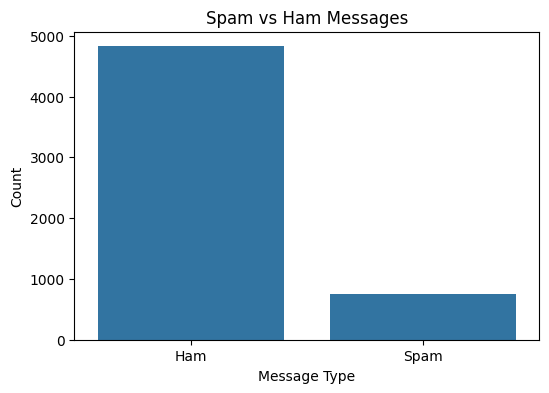

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'].replace({0:'Ham',1:'Spam'}))
plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [14]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


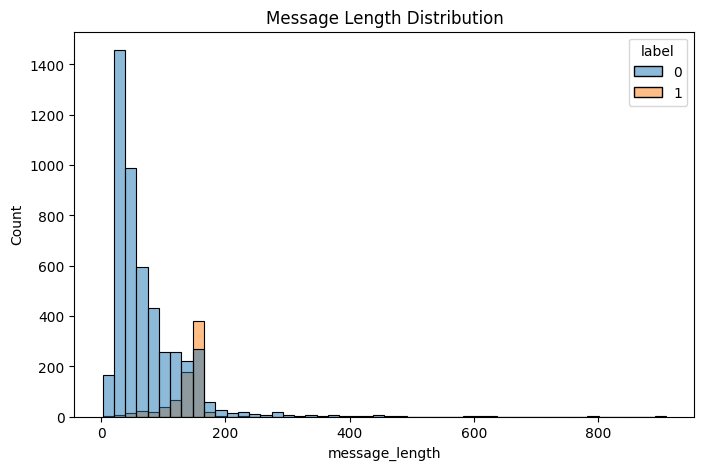

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50
)
plt.title("Message Length Distribution")
plt.show()

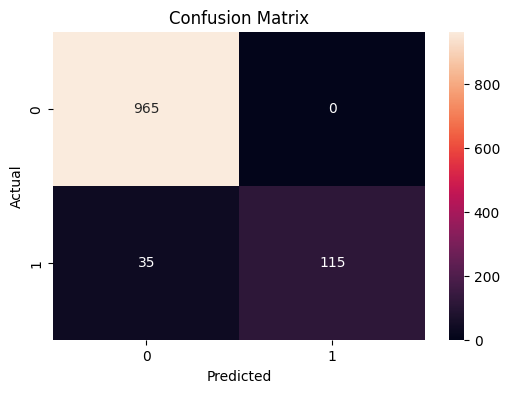

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

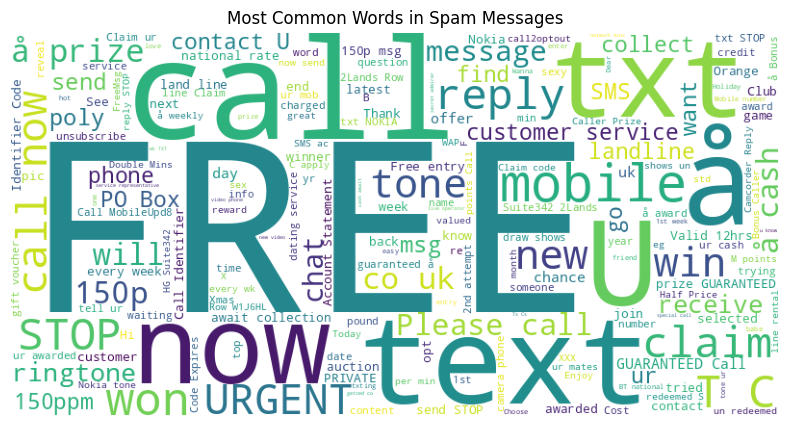

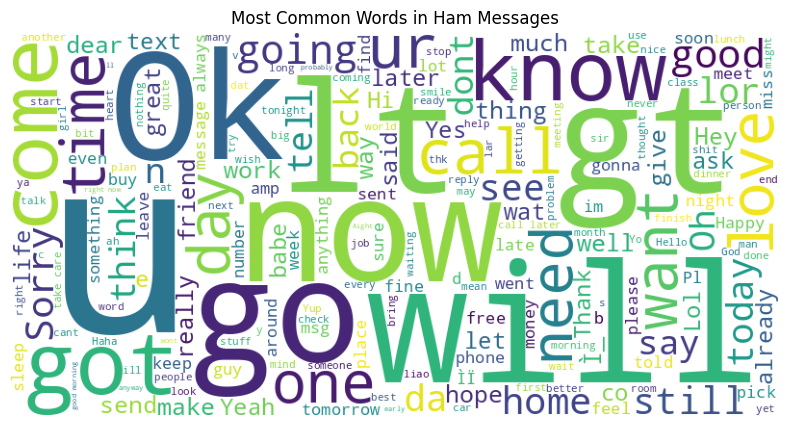

In [17]:
!pip install wordcloud
from wordcloud import WordCloud
spam_words = " ".join(
    df[df['label']==1]['message']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.show()


ham_words = " ".join(
    df[df['label']==0]['message']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Ham Messages")
plt.show()

## Conclusion

In this project, a Spam Mail Detector was developed using Machine Learning and Natural Language Processing techniques. The SMS Spam Collection dataset was used to train and test the model. The text messages were preprocessed and converted into numerical features using the TF-IDF vectorization technique. A Multinomial Naive Bayes classifier was then trained to classify messages as either Spam or Ham.

The model achieved high accuracy in detecting unwanted messages and demonstrated the effectiveness of machine learning in text classification tasks. Various visualizations, including message distribution, message length analysis, word clouds, and confusion matrix heatmaps, were used to better understand the dataset and evaluate the model's performance.

This project provided practical experience in data preprocessing, feature extraction, text classification, model evaluation, and data visualization. It also highlighted the importance of spam detection systems in improving communication security and reducing unwanted messages.
